In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df =pd.read_csv("/csl/users/2026nnandaku/cluster/HackTJ_Weather_Pred/weather_forecast_data.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


In [18]:
df.columns

Index(['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure',
       'Rain'],
      dtype='object')

In [19]:
df.describe()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,22.581725,64.347094,9.906255,49.658104,1014.312336
std,7.326996,19.954739,5.780316,29.123104,20.196433
min,10.001842,30.005071,0.009819,0.015038,980.014486
25%,16.359398,47.339815,4.761909,23.900016,996.938630
50%,22.536448,63.920797,9.908572,49.488284,1013.433035
75%,28.976476,81.561021,14.948408,75.324140,1031.735067
max,34.995214,99.997481,19.999132,99.997795,1049.985593


In [20]:
df['Rain']

0          rain
1       no rain
2       no rain
3          rain
4       no rain
         ...   
2495    no rain
2496    no rain
2497    no rain
2498    no rain
2499    no rain
Name: Rain, Length: 2500, dtype: object

In [21]:
df[df.columns].isnull().sum()

Temperature    0
Humidity       0
Wind_Speed     0
Cloud_Cover    0
Pressure       0
Rain           0
dtype: int64

In [22]:
df.head()


,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


Text(0, 0.5, 'Cloud_Cover')

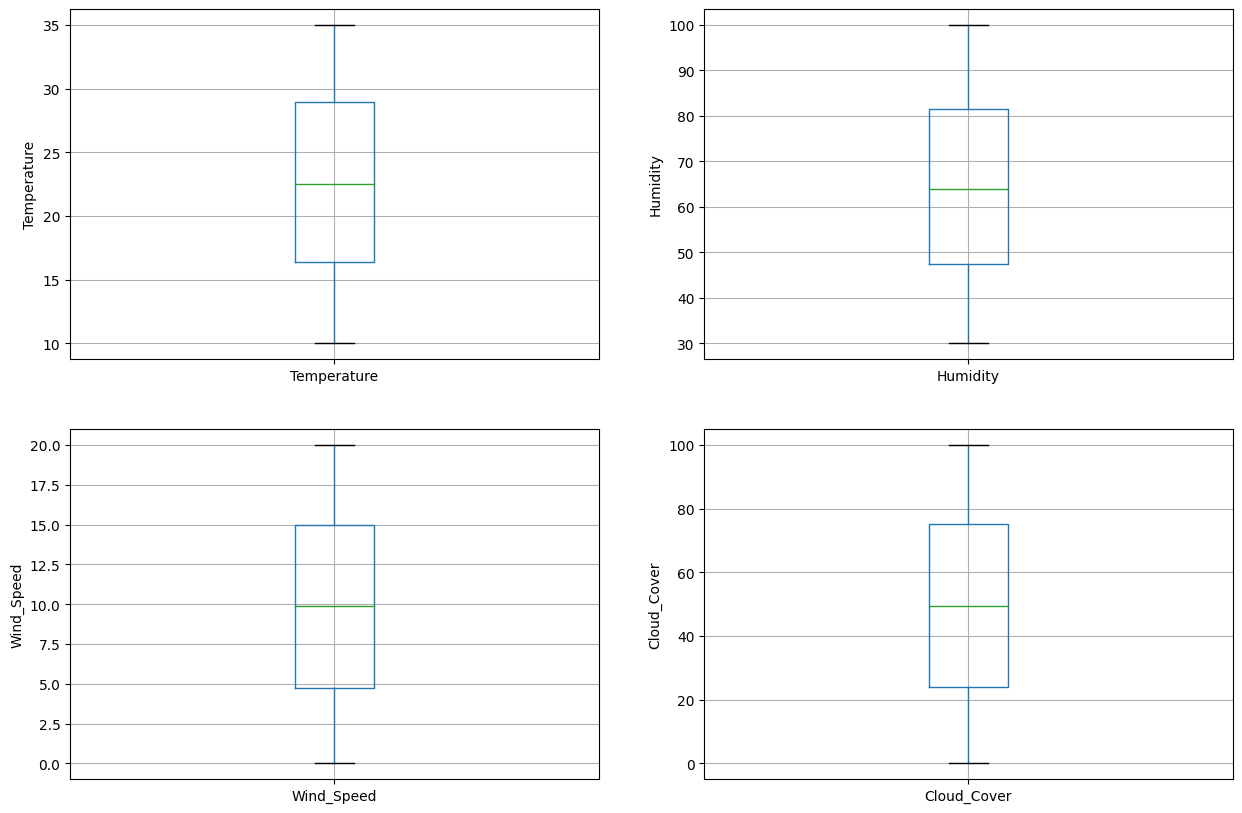

In [23]:
plt.figure(figsize=(15,10))


plt.subplot(2, 2, 1)
fig = df.boxplot(column='Temperature')
fig.set_title('')
fig.set_ylabel('Temperature')


plt.subplot(2, 2, 2)
fig = df.boxplot(column='Humidity')
fig.set_title('')
fig.set_ylabel('Humidity')


plt.subplot(2, 2, 3)
fig = df.boxplot(column='Wind_Speed')
fig.set_title('')
fig.set_ylabel('Wind_Speed')


plt.subplot(2, 2, 4)
fig = df.boxplot(column='Cloud_Cover')
fig.set_title('')
fig.set_ylabel('Cloud_Cover')

<Axes: >

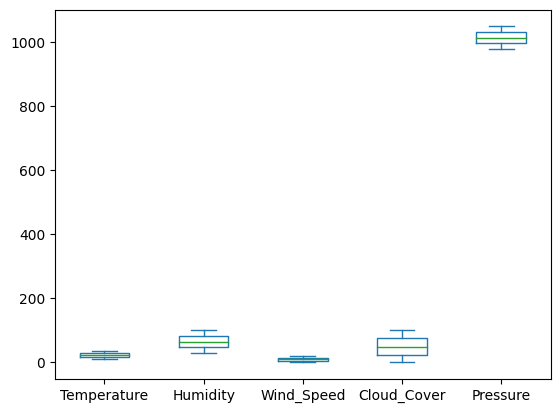

In [24]:
df.plot(kind='box')

<Axes: ylabel='Density'>

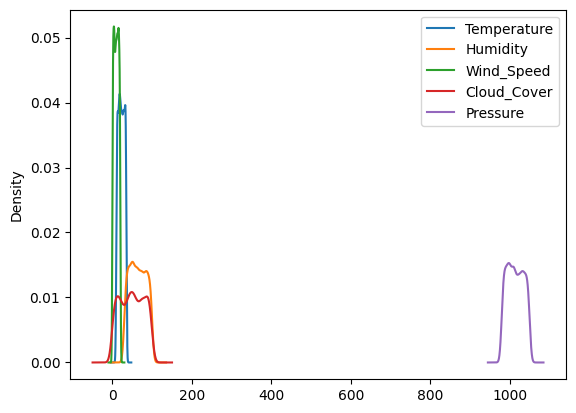

In [25]:
df.plot(kind='kde')

In [26]:
for i in df.columns[:5]:
    print(i, df[i].skew())

Temperature 0.007618604325515087
Humidity 0.04910703372687981
Wind_Speed 0.001099742391592177
Cloud_Cover -0.014710527157822659
Pressure 0.05408319915373729


In [27]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [28]:
from sklearn.model_selection import train_test_split

X = df.drop('Rain',axis=1)
y = df['Rain']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

X_train.shape, X_test.shape

((2000, 5), (500, 5))

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df["Rain"] = df["Rain"].map({"rain": 1, "no rain": 0})

df = df.dropna()

X = df.drop("Rain", axis=1)
y = df["Rain"]

X_train, X_test = X.iloc[:2000], X.iloc[-500:]
y_train, y_test = y.iloc[:2000], y.iloc[-500:]

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf)
classification_rep = classification_report(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_rep)

Random Forest Performance:
Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       438
           1       1.00      1.00      1.00        62

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



In [38]:
import warnings
warnings.filterwarnings("ignore")
def predict_rain(temperature, humidity, wind_speed, cloud_cover, pressure):
    input_data = [[temperature, humidity, wind_speed, cloud_cover, pressure]]
    print(f"Input data: {input_data}")
    
    prediction = rf_model.predict(input_data)[0]
    result = "rain" if prediction == 1 else "no rain"
    print(f"Prediction: {result}")
    return result

predict_rain(15.6, 120.6, 8.23, 51.55, 1045.6)  

Input data: [[15.6, 120.6, 8.23, 51.55, 1045.6]]
Prediction: rain


'rain'